# 온라인 쇼핑객 Revenue 예측 - Random Forest 재분석

상위 폴더의 `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`를 사용해 Random Forest를 다시 분석한다.

분석 항목:
- 전처리된 train/test 데이터 로드 및 `PageValues` 누수 컬럼 확인
- train 기준 IQR 극단값 제거 후 동일 기준을 test에 적용
- `max_depth`에 따른 과적합 분석
- `gini` 외 `entropy`, `log_loss` criterion 비교
- F1 기준 RandomizedSearchCV 튜닝
- 최종 모델 성능, 혼동 행렬, 변수 중요도, 대표 트리 규칙 확인


In [1]:
%matplotlib inline

from pathlib import Path
import sys
import subprocess

modules = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
}
for mod, package in modules.items():
    try:
        __import__(mod)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
)
from sklearn.tree import export_text, plot_tree

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (8, 4.5)


## 1. 데이터 로드

현재 노트북 위치와 상위 폴더를 탐색해 루트의 전처리 산출물을 읽는다. `PageValues`가 남아 있으면 누수 가능성이 있으므로 제거한다.


In [2]:
def find_data_dir():
    required = ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']
    candidates = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([
            base / 'csv',
            base / 'models' / 'random_forest' / 'csv',
            base,
        ])
    for base in candidates:
        if all((base / name).exists() for name in required):
            return base
    raise FileNotFoundError('RF용 X/y train/test CSV 파일을 찾지 못했습니다.')

DATA_DIR = find_data_dir()
X_train_raw = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test_raw = pd.read_csv(DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').iloc[:, 0].astype(int).reset_index(drop=True)
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').iloc[:, 0].astype(int).reset_index(drop=True)

leakage_cols = [col for col in ['PageValues'] if col in X_train_raw.columns]
X_train = X_train_raw.drop(columns=leakage_cols).reset_index(drop=True)
X_test = X_test_raw.drop(columns=leakage_cols).reset_index(drop=True)

print(f'Data directory: {DATA_DIR}')
print(f'Train: {X_train.shape}, positive ratio: {y_train.mean():.4f}')
print(f'Test : {X_test.shape}, positive ratio: {y_test.mean():.4f}')
print(f'Removed leakage columns: {leakage_cols if leakage_cols else "None"}')
print(f'Feature count: {X_train.shape[1]}')
X_train.head()


Data directory: /Users/hyunkim/2026_2/datamining/shopper-prediction/models/random_forest/csv
Train: (9764, 31), positive ratio: 0.1563
Test : (2441, 31), positive ratio: 0.1565
Removed leakage columns: None
Feature count: 31


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,OperatingSystems,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,0.0,2,...,0,0,0,0,1,0,0,0,0,1
1,0,0.0,0,0.0,30,901.288889,0.0,0.007333,0.0,2,...,0,0,0,0,0,0,0,1,0,0
2,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.8,1,...,0,0,0,1,0,0,0,0,0,1
3,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.0,2,...,0,0,1,0,0,0,0,1,0,0
4,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.0,4,...,0,0,0,1,0,0,0,0,0,1


## 2. 극단값 제거

극단값 경계는 train에서만 계산한다. 동일 경계를 test에 적용해 평가 데이터에도 같은 전처리 기준을 사용한다.


In [3]:
OUTLIER_CANDIDATES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'SpecialDay',
    'total_pages', 'total_duration', 'avg_time_per_product', 'bounce_exit_ratio',
]
outlier_cols = [col for col in OUTLIER_CANDIDATES if col in X_train.columns]

q1 = X_train[outlier_cols].quantile(0.25)
q3 = X_train[outlier_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
active_outlier_cols = iqr[iqr > 0].index.tolist()

def inlier_mask(X):
    if not active_outlier_cols:
        return pd.Series(True, index=X.index)
    return ((X[active_outlier_cols] >= lower[active_outlier_cols]) &
            (X[active_outlier_cols] <= upper[active_outlier_cols])).all(axis=1)

train_mask = inlier_mask(X_train)
test_mask = inlier_mask(X_test)

X_train_clean = X_train.loc[train_mask].reset_index(drop=True)
y_train_clean = y_train.loc[train_mask].reset_index(drop=True)
X_test_clean = X_test.loc[test_mask].reset_index(drop=True)
y_test_clean = y_test.loc[test_mask].reset_index(drop=True)

removed_train = len(X_train) - len(X_train_clean)
removed_test = len(X_test) - len(X_test_clean)
print(f'Outlier columns: {active_outlier_cols}')
print(f'Train removed: {removed_train:,} / {len(X_train):,} ({removed_train / len(X_train):.2%})')
print(f'Test removed : {removed_test:,} / {len(X_test):,} ({removed_test / len(X_test):.2%})')
print(f'Clean train: {X_train_clean.shape}, positive ratio: {y_train_clean.mean():.4f}')
print(f'Clean test : {X_test_clean.shape}, positive ratio: {y_test_clean.mean():.4f}')


Outlier columns: ['Administrative', 'Administrative_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'total_pages', 'total_duration', 'avg_time_per_product', 'bounce_exit_ratio']
Train removed: 3,303 / 9,764 (33.83%)
Test removed : 813 / 2,441 (33.31%)
Clean train: (6461, 31), positive ratio: 0.1568
Clean test : (1628, 31), positive ratio: 0.1548


## 3. 평가 함수

불균형 분류이므로 Accuracy만 보지 않고 Precision, Recall, F1, ROC-AUC, PR-AUC를 함께 본다.


In [4]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_eval)[:, 1]
    else:
        y_prob = y_pred
    return {
        'model': name,
        'accuracy': accuracy_score(y_eval, y_pred),
        'precision': precision_score(y_eval, y_pred, zero_division=0),
        'recall': recall_score(y_eval, y_pred, zero_division=0),
        'f1': f1_score(y_eval, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_eval, y_prob),
        'pr_auc': average_precision_score(y_eval, y_prob),
    }


## 4. 깊이에 따른 과적합 분석

`max_depth`가 커질수록 train F1과 validation F1이 어떻게 벌어지는지 확인한다. Random Forest도 각 트리가 깊어지면 학습 데이터에 과하게 맞을 수 있다.


max_depth  train_f1  val_f1  train_accuracy  val_accuracy
        2    0.3670  0.3847          0.6062        0.6265
        4    0.3901  0.3905          0.6515        0.6620
        6    0.4500  0.4055          0.7096        0.7007
        8    0.5423  0.4103          0.7825        0.7355
       10    0.6633  0.3792          0.8589        0.7595
       12    0.7715  0.3538          0.9145        0.7881
       16    0.9229  0.2708          0.9747        0.8167
     None    0.9742  0.2079          0.9919        0.8291

Validation F1 기준 최적 깊이: 8 (val_f1=0.4103, train_f1=0.5423)


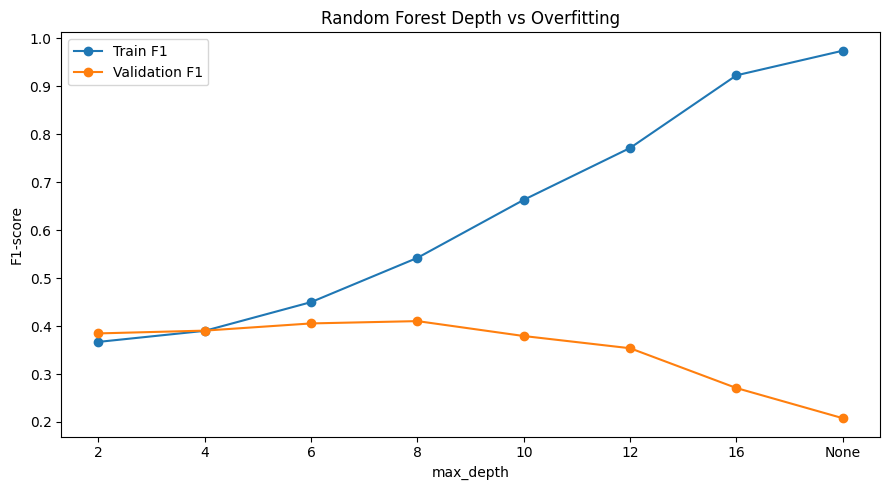

In [5]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_clean,
    y_train_clean,
    test_size=0.2,
    stratify=y_train_clean,
    random_state=RANDOM_STATE,
)

depth_candidates = [2, 4, 6, 8, 10, 12, 16, None]
depth_rows = []
for depth in depth_candidates:
    model = RandomForestClassifier(
        n_estimators=200,
        criterion='gini',
        max_depth=depth,
        min_samples_leaf=3,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_tr, y_tr)
    depth_rows.append({
        'max_depth': 'None' if depth is None else depth,
        'train_f1': f1_score(y_tr, model.predict(X_tr)),
        'val_f1': f1_score(y_val, model.predict(X_val)),
        'train_accuracy': accuracy_score(y_tr, model.predict(X_tr)),
        'val_accuracy': accuracy_score(y_val, model.predict(X_val)),
    })

depth_result = pd.DataFrame(depth_rows)
best_depth_row = depth_result.loc[depth_result['val_f1'].idxmax()]
print(depth_result.round(4).to_string(index=False))
print(f"\nValidation F1 기준 최적 깊이: {best_depth_row['max_depth']} "
      f"(val_f1={best_depth_row['val_f1']:.4f}, train_f1={best_depth_row['train_f1']:.4f})")

plot_depth = depth_result.copy()
plot_depth['depth_label'] = plot_depth['max_depth'].astype(str)
plt.figure(figsize=(9, 5))
plt.plot(plot_depth['depth_label'], plot_depth['train_f1'], marker='o', label='Train F1')
plt.plot(plot_depth['depth_label'], plot_depth['val_f1'], marker='o', label='Validation F1')
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.title('Random Forest Depth vs Overfitting')
plt.legend()
plt.tight_layout()
plt.show()


## 5. criterion 비교

Random Forest의 `criterion`은 `gini` 외에 `entropy`, `log_loss`를 사용할 수 있다. 현재 설치된 scikit-learn에서 지원되는 criterion만 후보로 사용한다.


In [6]:
def supported_criteria(criteria):
    ok = []
    sample_X = X_train_clean.head(100)
    sample_y = y_train_clean.head(100)
    for criterion in criteria:
        try:
            RandomForestClassifier(
                n_estimators=5,
                criterion=criterion,
                random_state=RANDOM_STATE,
            ).fit(sample_X, sample_y)
            ok.append(criterion)
        except ValueError:
            pass
    return ok

criteria = supported_criteria(['gini', 'entropy', 'log_loss'])
criterion_rows = []
for criterion in criteria:
    model = RandomForestClassifier(
        n_estimators=200,
        criterion=criterion,
        max_depth=best_depth_row['max_depth'] if best_depth_row['max_depth'] != 'None' else None,
        min_samples_leaf=3,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_tr, y_tr)
    criterion_rows.append(evaluate_model(criterion, model, X_val, y_val))

criterion_result = pd.DataFrame(criterion_rows).sort_values('f1', ascending=False)
print(f'Criterion candidates: {criteria}')
criterion_result.round(4)


Criterion candidates: ['gini', 'entropy', 'log_loss']


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,gini,0.7355,0.3156,0.5862,0.4103,0.7509,0.3536
1,entropy,0.7270,0.3096,0.6010,0.4087,0.7538,0.3537
2,log_loss,0.7270,0.3096,0.6010,0.4087,0.7538,0.3537


## 6. 하이퍼파라미터 튜닝

F1을 기준으로 `criterion`, `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`, `n_estimators`를 탐색한다.


In [7]:
param_distributions = {
    'n_estimators': [150, 250, 350],
    'criterion': criteria,
    'max_depth': [4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 10, 30, 50],
    'min_samples_leaf': [1, 3, 5, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def run_rf_search(scoring, label):
    search = RandomizedSearchCV(
        estimator=RandomForestClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        param_distributions=param_distributions,
        n_iter=60,
        scoring=scoring,
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True,
    )
    search.fit(X_train_clean, y_train_clean)

    result_df = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
    summary_cols = [
        'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score',
        'param_n_estimators', 'param_criterion', 'param_max_depth',
        'param_min_samples_leaf', 'param_min_samples_split', 'param_max_features',
    ]
    print(f'Best params - {label}:')
    print(search.best_params_)
    print(f"Best CV {label}: {search.best_score_:.4f}")
    print(f'\nTop 10 tuning results - {label}:')
    print(result_df[summary_cols].head(10).round(4).to_string(index=False))
    print('\n' + '-' * 80 + '\n')
    return search, result_df

f1_search, f1_cv_result = run_rf_search('f1', 'F1')
precision_search, precision_cv_result = run_rf_search('precision', 'Precision')


Best params - F1:
{'n_estimators': 150, 'min_samples_split': 50, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'entropy'}
Best CV F1: 0.3997

Top 10 tuning results - F1:
 rank_test_score  mean_test_score  std_test_score  mean_train_score  param_n_estimators param_criterion param_max_depth  param_min_samples_leaf  param_min_samples_split param_max_features
               1           0.3997          0.0155            0.5329                 150         entropy              10                       5                       50               sqrt
               2           0.3983          0.0190            0.5572                 150         entropy              12                       5                       50               log2
               3           0.3970          0.0193            0.5763                 150        log_loss              12                      10                       30               log2
               4           0.3962          0.01

Best params - Precision:
{'n_estimators': 350, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2', 'max_depth': None, 'criterion': 'gini'}
Best CV Precision: 0.3689

Top 10 tuning results - Precision:
 rank_test_score  mean_test_score  std_test_score  mean_train_score  param_n_estimators param_criterion param_max_depth  param_min_samples_leaf  param_min_samples_split param_max_features
               1           0.3689          0.0327            0.9514                 350            gini            None                       3                        2               log2
               2           0.3644          0.0350            0.9557                 250         entropy            None                       3                        2               log2
               3           0.3390          0.0174            0.6726                 350            gini            None                       1                       30               log2
               4           0

## 7. 최종 모델 평가

튜닝된 모델을 극단값 제거 후 train 전체에 학습한 결과로 test 성능을 확인한다.


In [8]:
default_model = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
default_model.fit(X_train_clean, y_train_clean)

best_f1_model = f1_search.best_estimator_
best_precision_model = precision_search.best_estimator_

# 기존 분석 셀과 호환되도록 F1 기준 모델을 기본 tuned 모델로 둔다.
best_model = best_f1_model

def prediction_bundle(model, X_eval):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    return y_pred, y_prob

y_pred_f1, y_prob_f1 = prediction_bundle(best_f1_model, X_test_clean)
y_pred_precision, y_prob_precision = prediction_bundle(best_precision_model, X_test_clean)

# 기존 변수명은 F1 기준 tuned model을 가리키도록 유지한다.
y_pred = y_pred_f1
y_prob = y_prob_f1

metrics = pd.DataFrame([
    evaluate_model('Random Forest default after outlier removal', default_model, X_test_clean, y_test_clean),
    evaluate_model('Random Forest tuned by F1', best_f1_model, X_test_clean, y_test_clean),
    evaluate_model('Random Forest tuned by Precision', best_precision_model, X_test_clean, y_test_clean),
])
print(metrics.round(4).to_string(index=False))

print('\nClassification report - F1 tuned model:')
print(classification_report(y_test_clean, y_pred_f1, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('Best F1-tuned params:')
print(f1_search.best_params_)

print('\nClassification report - Precision tuned model:')
print(classification_report(y_test_clean, y_pred_precision, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('Best Precision-tuned params:')
print(precision_search.best_params_)


                                      model  accuracy  precision  recall     f1  roc_auc  pr_auc
Random Forest default after outlier removal    0.8452     0.5000  0.0397 0.0735   0.7536  0.3359
                  Random Forest tuned by F1    0.7156     0.2943  0.5992 0.3948   0.7646  0.3619
           Random Forest tuned by Precision    0.8397     0.4634  0.2262 0.3040   0.7657  0.3552

Classification report - F1 tuned model:
              precision    recall  f1-score   support

 No Purchase       0.91      0.74      0.81      1376
    Purchase       0.29      0.60      0.39       252

    accuracy                           0.72      1628
   macro avg       0.60      0.67      0.60      1628
weighted avg       0.81      0.72      0.75      1628

Best F1-tuned params:
{'n_estimators': 150, 'min_samples_split': 50, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10, 'criterion': 'entropy'}

Classification report - Precision tuned model:
              precision    recall  f1-s

## 8. 혼동 행렬, ROC/PR 곡선, 변수 중요도

그래프는 파일로 저장하지 않고 노트북 출력으로만 확인한다.


F1 tuned confusion matrix


,Pred No Purchase,Pred Purchase
Actual No Purchase,1014,362
Actual Purchase,101,151


Precision tuned confusion matrix


,Pred No Purchase,Pred Purchase
Actual No Purchase,1310,66
Actual Purchase,195,57


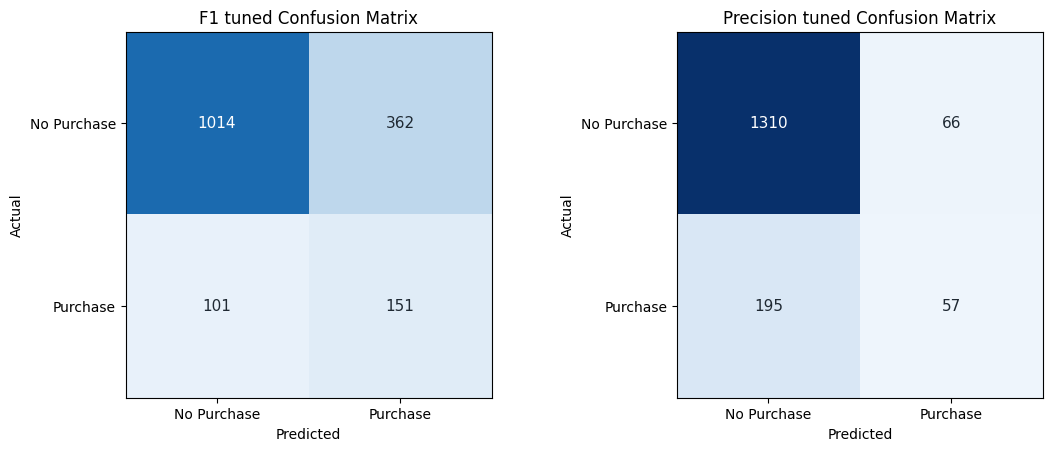

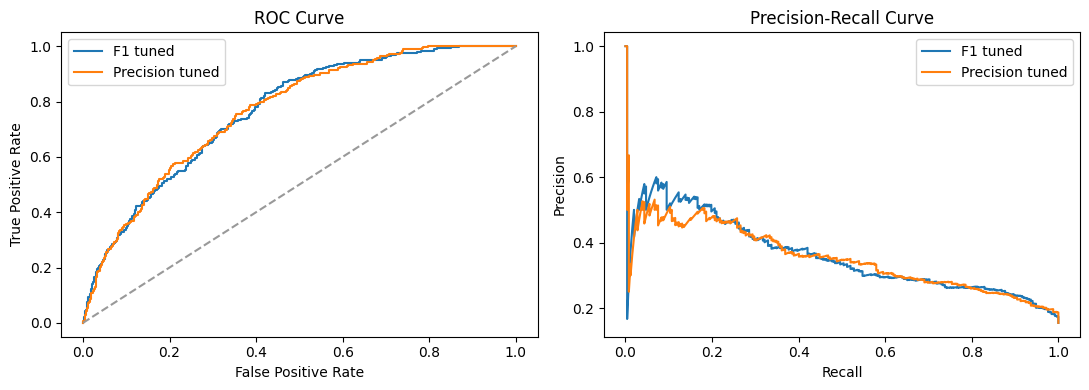

F1 tuned top 15 feature importance


,model,feature,importance
7,F1 tuned,ExitRates,0.1575
5,F1 tuned,ProductRelated_Duration,0.1028
15,F1 tuned,total_duration,0.0923
16,F1 tuned,avg_time_per_product,0.0802
4,F1 tuned,ProductRelated,0.0533
6,F1 tuned,BounceRates,0.0532
14,F1 tuned,total_pages,0.0511
1,F1 tuned,Administrative_Duration,0.0503
0,F1 tuned,Administrative,0.0436
17,F1 tuned,bounce_exit_ratio,0.0381


Precision tuned top 15 feature importance


,model,feature,importance
7,Precision tuned,ExitRates,0.1195
5,Precision tuned,ProductRelated_Duration,0.0973
15,Precision tuned,total_duration,0.0950
16,Precision tuned,avg_time_per_product,0.0902
4,Precision tuned,ProductRelated,0.0671
14,Precision tuned,total_pages,0.0654
1,Precision tuned,Administrative_Duration,0.0582
6,Precision tuned,BounceRates,0.0447
0,Precision tuned,Administrative,0.0421
17,Precision tuned,bounce_exit_ratio,0.0415


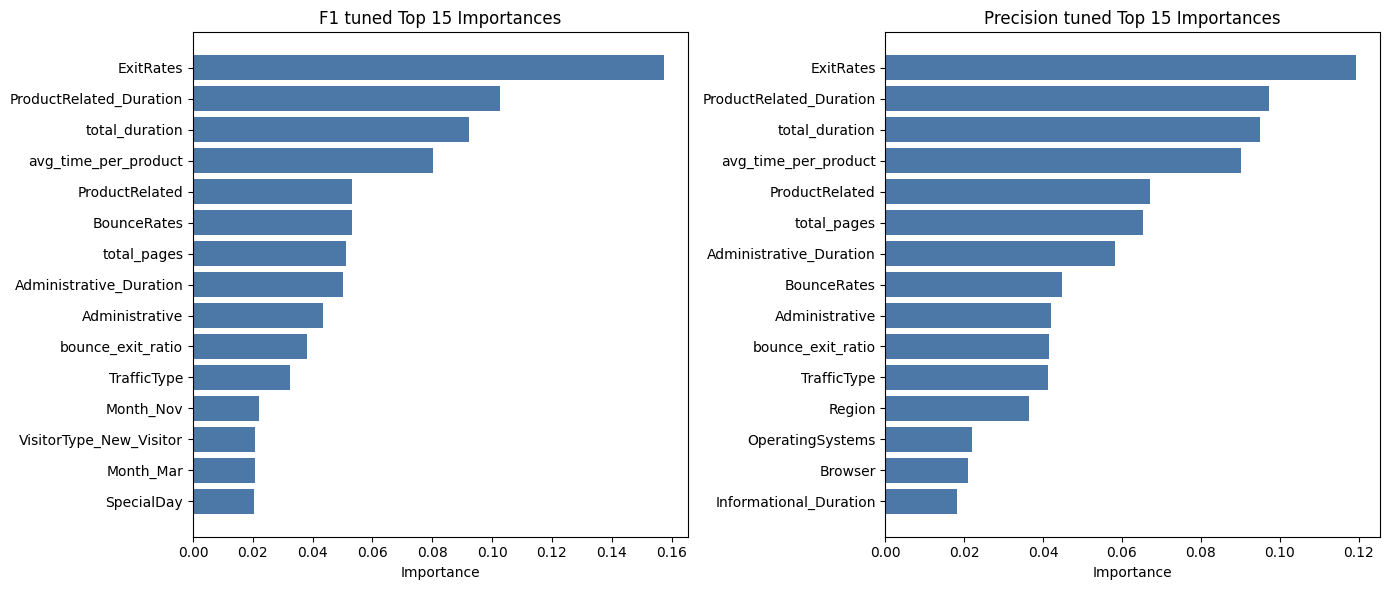

In [9]:
model_outputs = {
    'F1 tuned': {
        'model': best_f1_model,
        'y_pred': y_pred_f1,
        'y_prob': y_prob_f1,
    },
    'Precision tuned': {
        'model': best_precision_model,
        'y_pred': y_pred_precision,
        'y_prob': y_prob_precision,
    },
}

for name, output in model_outputs.items():
    cm = confusion_matrix(y_test_clean, output['y_pred'])
    confusion = pd.DataFrame(
        cm,
        index=['Actual No Purchase', 'Actual Purchase'],
        columns=['Pred No Purchase', 'Pred Purchase'],
    )
    print(f'{name} confusion matrix')
    display(confusion)

confusion_matrices = {
    name: confusion_matrix(y_test_clean, output['y_pred'])
    for name, output in model_outputs.items()
}
max_count = max(cm.max() for cm in confusion_matrices.values())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=max_count)
    ax.set_xticks([0, 1], ['No Purchase', 'Purchase'])
    ax.set_yticks([0, 1], ['No Purchase', 'Purchase'])
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            value = cm[row, col]
            text_color = 'white' if value > max_count * 0.55 else '#1f2933'
            ax.text(col, row, str(value), ha='center', va='center', color=text_color, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} Confusion Matrix')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, output in model_outputs.items():
    fpr, tpr, _ = roc_curve(y_test_clean, output['y_prob'])
    precision, recall, _ = precision_recall_curve(y_test_clean, output['y_prob'])
    axes[0].plot(fpr, tpr, label=name)
    axes[1].plot(recall, precision, label=name)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='#999999')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
plt.tight_layout()
plt.show()

importance_tables = []
for name, output in model_outputs.items():
    importance = (
        pd.DataFrame({
            'model': name,
            'feature': X_train_clean.columns,
            'importance': output['model'].feature_importances_,
        })
        .sort_values('importance', ascending=False)
    )
    importance_tables.append(importance)
    print(f'{name} top 15 feature importance')
    display(importance.head(15).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, importance in zip(axes, importance_tables):
    name = importance['model'].iloc[0]
    plot_df = importance.head(15).sort_values('importance')
    ax.barh(plot_df['feature'], plot_df['importance'], color='#4c78a8')
    ax.set_title(f'{name} Top 15 Importances')
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

feature_importance = importance_tables[0].drop(columns=['model'])


## 9. 대표 트리 규칙

Random Forest 전체는 여러 트리의 앙상블이므로 완전한 단일 규칙으로 설명되지는 않는다. 대신 첫 번째 트리를 깊이 3까지만 출력해 대표적인 분기 방향을 확인한다.


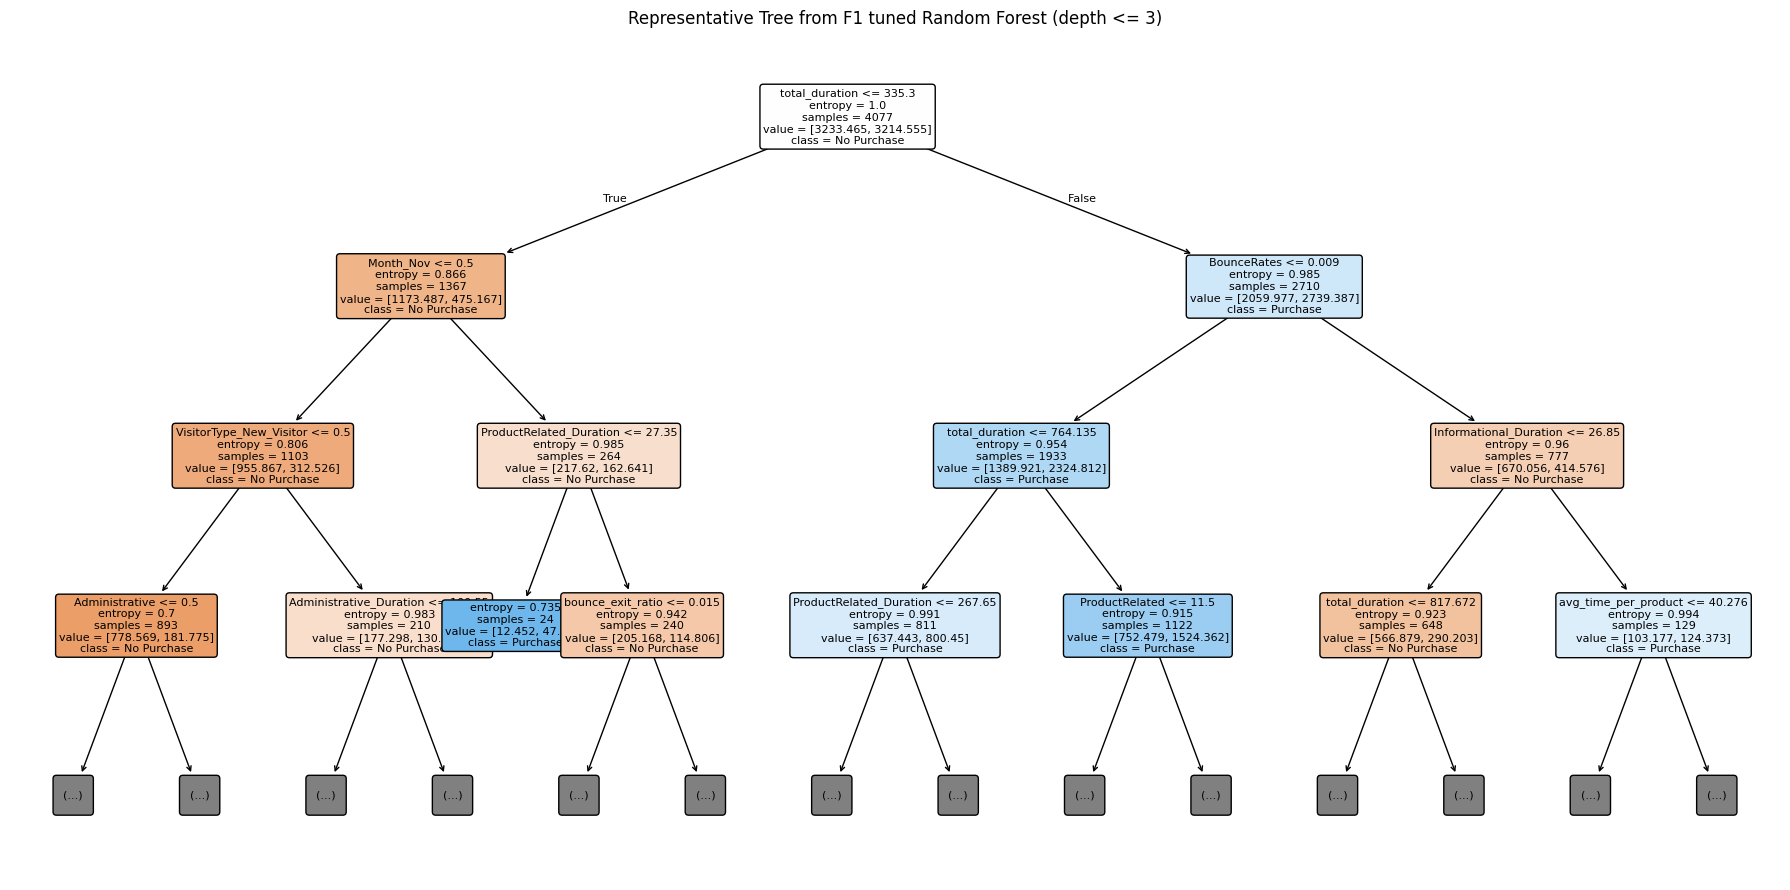

--- F1 tuned representative tree rules ---
|--- total_duration <= 335.30
|   |--- Month_Nov <= 0.50
|   |   |--- VisitorType_New_Visitor <= 0.50
|   |   |   |--- Administrative <= 0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- Administrative >  0.50
|   |   |   |   |--- truncated branch of depth 7
|   |   |--- VisitorType_New_Visitor >  0.50
|   |   |   |--- Administrative_Duration <= 100.55
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- Administrative_Duration >  100.55
|   |   |   |   |--- class: 0.0
|   |--- Month_Nov >  0.50
|   |   |--- ProductRelated_Duration <= 27.35
|   |   |   |--- class: 1.0
|   |   |--- ProductRelated_Duration >  27.35
|   |   |   |--- bounce_exit_ratio <= 0.02
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- bounce_exit_ratio >  0.02
|   |   |   |   |--- truncated branch of depth 3
|--- total_duration >  335.30
|   |--- BounceRates <= 0.01
|   |   |--- total_duration <= 764.14
|   |   |   |--- Prod

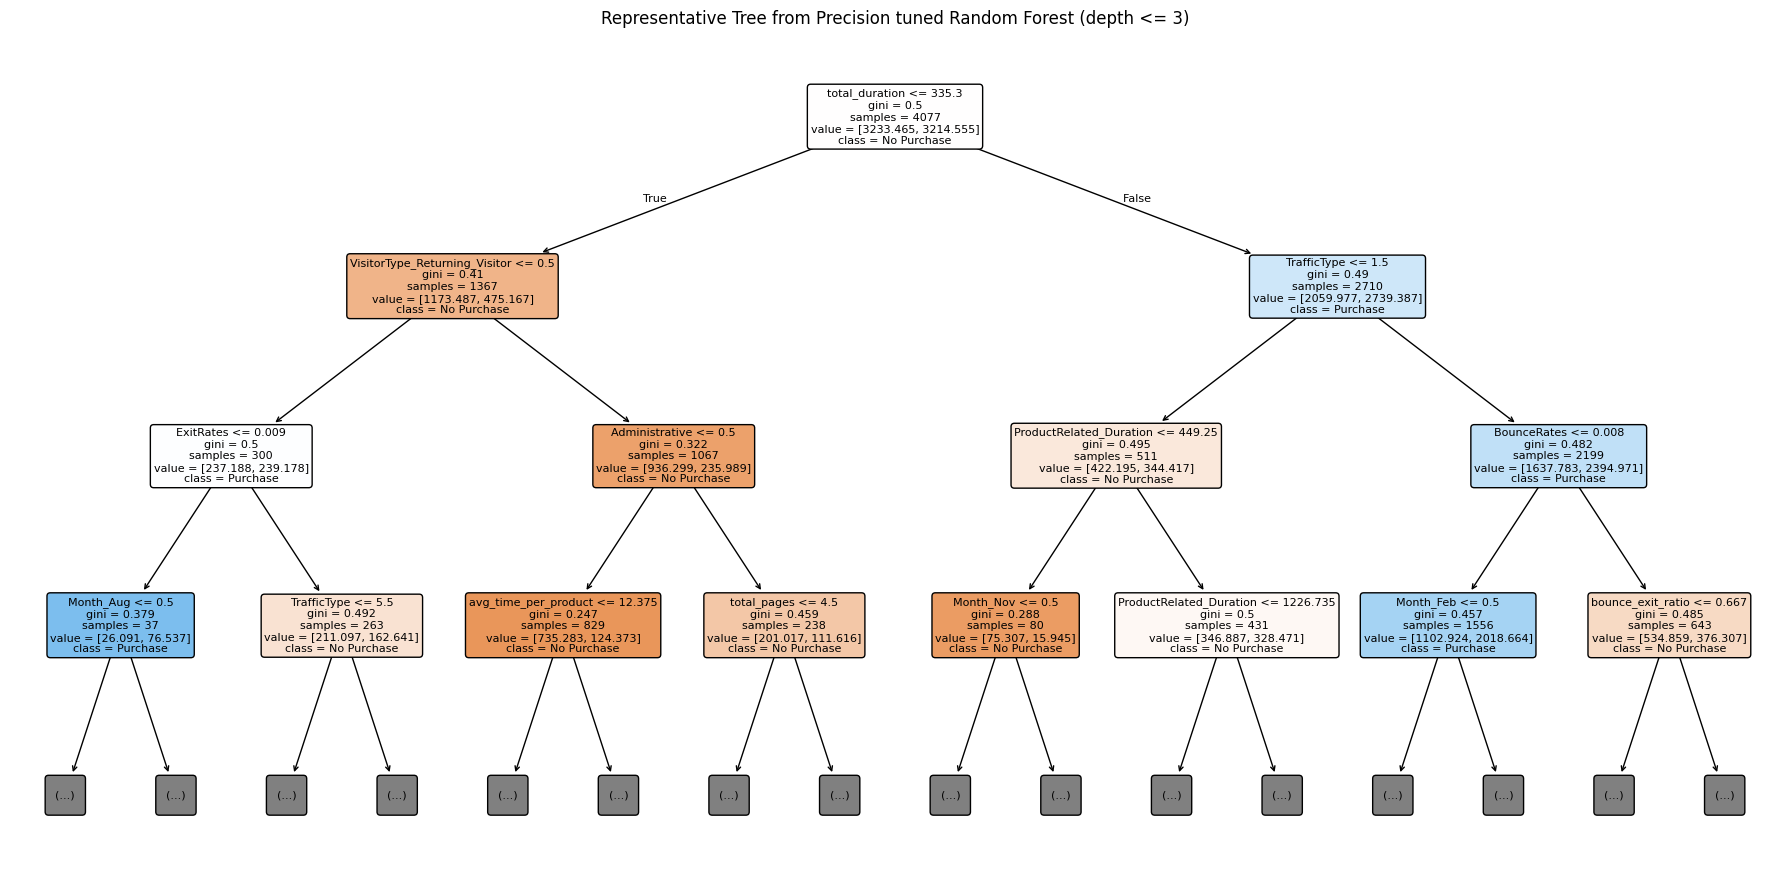

--- Precision tuned representative tree rules ---
|--- total_duration <= 335.30
|   |--- VisitorType_Returning_Visitor <= 0.50
|   |   |--- ExitRates <= 0.01
|   |   |   |--- Month_Aug <= 0.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Month_Aug >  0.50
|   |   |   |   |--- class: 1.0
|   |   |--- ExitRates >  0.01
|   |   |   |--- TrafficType <= 5.50
|   |   |   |   |--- truncated branch of depth 13
|   |   |   |--- TrafficType >  5.50
|   |   |   |   |--- truncated branch of depth 8
|   |--- VisitorType_Returning_Visitor >  0.50
|   |   |--- Administrative <= 0.50
|   |   |   |--- avg_time_per_product <= 12.37
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- avg_time_per_product >  12.37
|   |   |   |   |--- truncated branch of depth 14
|   |   |--- Administrative >  0.50
|   |   |   |--- total_pages <= 4.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- total_pages >  4.50
|   |   |   |   |--- truncated branch of depth 14
|-

In [10]:
for name, model in [('F1 tuned', best_f1_model), ('Precision tuned', best_precision_model)]:
    fig, ax = plt.subplots(figsize=(18, 9))
    plot_tree(
        model.estimators_[0],
        feature_names=list(X_train_clean.columns),
        class_names=['No Purchase', 'Purchase'],
        filled=True,
        rounded=True,
        max_depth=3,
        fontsize=8,
        ax=ax,
    )
    ax.set_title(f'Representative Tree from {name} Random Forest (depth <= 3)')
    plt.tight_layout()
    plt.show()

    print(f'--- {name} representative tree rules ---')
    print(export_text(
        model.estimators_[0],
        feature_names=list(X_train_clean.columns),
        max_depth=3,
    ))
